In [41]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# --- Physical Constants ---
PHI_0 = 2.067833848e-15       # Magnetic flux quantum [Wb]
HBAR_2E = PHI_0 / (2 * np.pi) # Reduced flux quantum [Wb/rad]

# --- Global Device Parameters ---
wp = 1000 * 10**9             # Plasma frequency [rad/s] (1 THz)
Q_single = 0.5                # Single JJ Quality factor (Overdamped)
Q_squid = 0.5                 # SQUID Quality factor
beta_L = 0.05                 # SQUID geometric screening parameter
i_b = 2.1                     # Dimensionless SQUID bias current (i_b = I_bias / I_c)
R = 5.0                       # Shunt resistance [Ohms]
C = 1e-12                     # Capacitance [Farads]
Ic = 100e-6                   # Critical current per junction [Amps]
Ib = 2.1 * Ic                 # Total dimensional bias current [Amps]

# --- Core Physics Functions ---
def phase_dot(v):
    """Converts instantaneous voltage to phase evolution rate via AC Josephson effect."""
    return (2 * np.pi * v) / PHI_0

def get_jj_accel(phi, phi_dot, i_eff, Q):
    """Calculates dimensionless phase acceleration (phi_ddot) for the RCSJ model."""
    return i_eff - (1.0 / Q) * phi_dot - np.sin(phi)

def squid_deriv(phi, t, I_total):
    """Differential equation for SQUID macroscopic phase evolution."""
    v = (Ib - I_total * np.sin(phi)) * R
    return phase_dot(v)

def simulate_single_jj(i_drive_val, Q_val, N_steps, dtau_step, init_state=(0.0, 0.0)):
    """Runs the numerical integration for a single unshunted/shunted Josephson Junction."""
    phi_init, v_init = init_state
    phi = np.zeros(N_steps)
    phi_dot = np.zeros(N_steps)
    
    phi[0], phi_dot[0] = phi_init, v_init
    
    for i in range(N_steps - 1):
        phi_ddot = get_jj_accel(phi[i], phi_dot[i], i_drive_val, Q_val)
        phi_dot[i + 1] = phi_dot[i] + dtau_step * phi_ddot
        phi[i + 1] = phi[i] + dtau_step * phi_dot[i]
        
    return phi, phi_dot

def simulate_squid_core(f_ext, N, dtau, init_states=(0.0, 0.0, 0.0, 0.0)):
    """Runs the core numerical integration for the coupled SQUID equations."""
    phi1_init, phi2_init, v1_init, v2_init = init_states
    phi1, phi2 = np.zeros(N), np.zeros(N)
    v1, v2 = np.zeros(N), np.zeros(N)
    
    phi1[0], phi2[0] = phi1_init, phi2_init
    v1[0], v2[0] = v1_init, v2_init
    
    for i in range(N - 1):
        j_circ = (phi1[i] - phi2[i] - 2 * np.pi * f_ext) / (np.pi * beta_L)
        
        i_eff_1 = (i_b / 2.0) - j_circ
        i_eff_2 = (i_b / 2.0) + j_circ
        
        phi1_ddot = get_jj_accel(phi1[i], v1[i], i_eff_1, Q_squid)
        phi2_ddot = get_jj_accel(phi2[i], v2[i], i_eff_2, Q_squid)
        
        v1[i + 1] = v1[i] + dtau * phi1_ddot
        v2[i + 1] = v2[i] + dtau * phi2_ddot
        phi1[i + 1] = phi1[i] + dtau * v1[i]
        phi2[i + 1] = phi2[i] + dtau * v2[i]
        
    v_squid_dim = (v1 + v2) / 2.0
    final_states = (phi1[-1], phi2[-1], v1[-1], v2[-1])
    
    return v_squid_dim, final_states

Simulating Single JJ Phase Evolution...
----------------------------------------
Integrating across 2571 timesteps (1 SFQ Pulse)...
Calculated Area (Flux) : 2.06762e-15 Wb
Theoretical 1 * Phi_0  : 2.06783e-15 Wb
Error                  : 0.01012 %
----------------------------------------


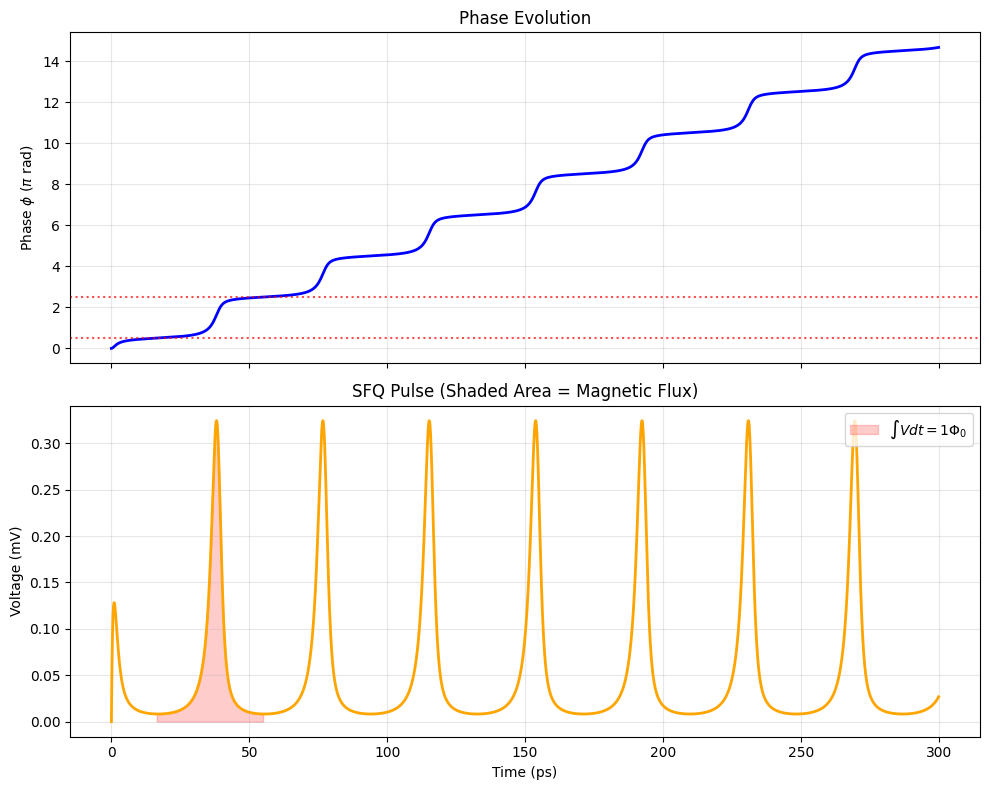

In [42]:
print("Simulating Single JJ Phase Evolution...")

# --- Single Junction Simulation Setup ---
i_drive = 1.05                # Driven slightly above critical current to induce phase slips
real_time_max = 300e-12       # Total simulation time [seconds] (300 ps)
tau_max = real_time_max * wp  # Convert to dimensionless time tau
N = 20000
tau, dtau = np.linspace(0, tau_max, N, retstep=True)

# --- Run Core Integration ---
phi, phi_dot = simulate_single_jj(i_drive, Q_single, N, dtau)

# --- Convert to Physical Units ---
time_s = tau / wp                      # [Seconds]
time_ps = time_s * 1e12                # [Picoseconds]
voltage_real = HBAR_2E * wp * phi_dot  # [Volts]
voltage_mV = voltage_real * 1e3        # [Millivolts]

# --- Verify Flux Quantization ---
# Bound the integration between two voltage minimums (0.5*pi to 2.5*pi) 
# to capture exactly one 2*pi phase rotation (One SFQ Pulse).
start_idx = np.argmax(phi > 0.5 * np.pi)
end_idx = np.argmax(phi > 2.5 * np.pi)

time_window = time_s[start_idx:end_idx]
voltage_window = voltage_real[start_idx:end_idx]

integrated_flux = np.trapezoid(voltage_window, time_window)
expected_flux = 1 * PHI_0

print("-" * 40)
print(f"Integrating across {len(time_window)} timesteps (1 SFQ Pulse)...")
print(f"Calculated Area (Flux) : {integrated_flux:.5e} Wb")
print(f"Theoretical 1 * Phi_0  : {expected_flux:.5e} Wb")
print(f"Error                  : {abs(integrated_flux - expected_flux) / expected_flux * 100:.5f} %")
print("-" * 40)

# --- Plotting Phase and Voltage ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1.plot(time_ps, phi / np.pi, color='blue', linewidth=2)
ax1.axhline(0.5, color='red', linestyle=':', alpha=0.7)
ax1.axhline(2.5, color='red', linestyle=':', alpha=0.7)
ax1.set_title('Phase Evolution')
ax1.set_ylabel(r'Phase $\phi$ ($\pi$ rad)')
ax1.grid(True, alpha=0.3)

ax2.plot(time_ps, voltage_mV, color='orange', linewidth=2)
ax2.fill_between(time_ps[start_idx:end_idx], voltage_mV[start_idx:end_idx], 
                 color='red', alpha=0.2, label=r'$\int V dt = 1 \Phi_0$')
ax2.set_title('SFQ Pulse (Shaded Area = Magnetic Flux)')
ax2.set_ylabel('Voltage (mV)')
ax2.set_xlabel('Time (ps)')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Simulating Microscopic Time-Domain Dynamics...


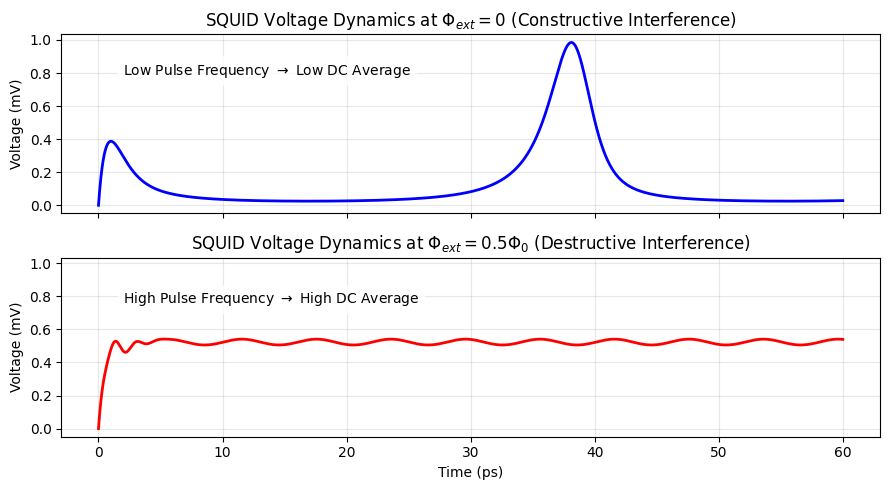

In [43]:
print("Simulating Microscopic Time-Domain Dynamics...")

real_time_max_td = 60e-12             # 60 ps window
tau_max_td = real_time_max_td * wp
N_td = 30000
tau_td, dtau_td = np.linspace(0, tau_max_td, N_td, retstep=True)
time_ps_td = (tau_td / wp) * 1e12

# Run simulation at max constructive (0.0) and max destructive (0.5) interference
# We ignore the final_states output here using the '_' placeholder
v_dim_min, _ = simulate_squid_core(0.0, N_td, dtau_td)
v_dim_max, _ = simulate_squid_core(0.5, N_td, dtau_td)

# Convert to physical voltage (mV) using characteristic voltage
V_CHAR_MV = (Ic * R / Q_squid) * 1e3
v_mV_min = v_dim_min * V_CHAR_MV
v_mV_max = v_dim_max * V_CHAR_MV

# --- Plotting Pulse Frequencies ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 5), sharex=True, sharey=True)

ax1.plot(time_ps_td, v_mV_min, color='blue', linewidth=2)
ax1.set_title(r'SQUID Voltage Dynamics at $\Phi_{ext} = 0$ (Constructive Interference)')
ax1.set_ylabel('Voltage (mV)')
ax1.grid(True, alpha=0.3)
ax1.text(2, np.max(v_mV_min)*0.8, 'Low Pulse Frequency $\\rightarrow$ Low DC Average', 
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

ax2.plot(time_ps_td, v_mV_max, color='red', linewidth=2)
ax2.set_title(r'SQUID Voltage Dynamics at $\Phi_{ext} = 0.5 \Phi_0$ (Destructive Interference)')
ax2.set_xlabel('Time (ps)')
ax2.set_ylabel('Voltage (mV)')
ax2.grid(True, alpha=0.3)
ax2.text(2, np.max(v_mV_max) * 1.4, 'High Pulse Frequency $\\rightarrow$ High DC Average', 
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

plt.tight_layout()
plt.show()

Simulating SQUID interference pattern...


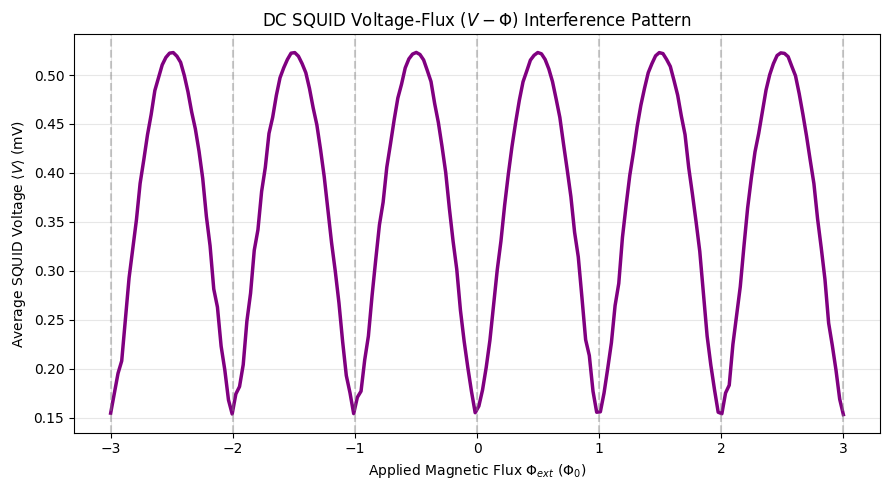

In [44]:
print("Simulating SQUID interference pattern...")

f_vals = np.linspace(-3, 3, 200)
v_avg_vals = np.zeros_like(f_vals)

tau_max = 500         
N_squid = 50000             
tau_sq, dtau_sq = np.linspace(0, tau_max, N_squid, retstep=True)

# Initialize states for adiabatic sweeping
current_states = (0.0, 0.0, 0.0, 0.0)

for k, f in enumerate(f_vals):
    # Run the core simulation for this flux value and capture the updated states
    v_squid_dim, current_states = simulate_squid_core(f, N_squid, dtau_sq, init_states=current_states)
    
    # Record steady-state average (discard first half of simulation to clear transients)
    v_avg_vals[k] = np.mean(v_squid_dim[N_squid // 2:]) 

# --- Unit Conversion ---
V_CHAR_MV = (Ic * R / Q_squid) * 1e3
v_squid_avg_mV = v_avg_vals * V_CHAR_MV

# --- Plotting Interference Pattern ---
plt.figure(figsize=(9, 5))
plt.plot(f_vals, v_squid_avg_mV, color='purple', linewidth=2.5)
plt.title(r'DC SQUID Voltage-Flux ($V-\Phi$) Interference Pattern')
plt.xlabel(r'Applied Magnetic Flux $\Phi_{ext}$ ($\Phi_0$)')
plt.ylabel(r'Average SQUID Voltage $\langle V \rangle$ (mV)')

for i in range(-3, 4):
    plt.axvline(i, color='gray', linestyle='--', alpha=0.4)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Simulating Physical Flux-Locked Loop...


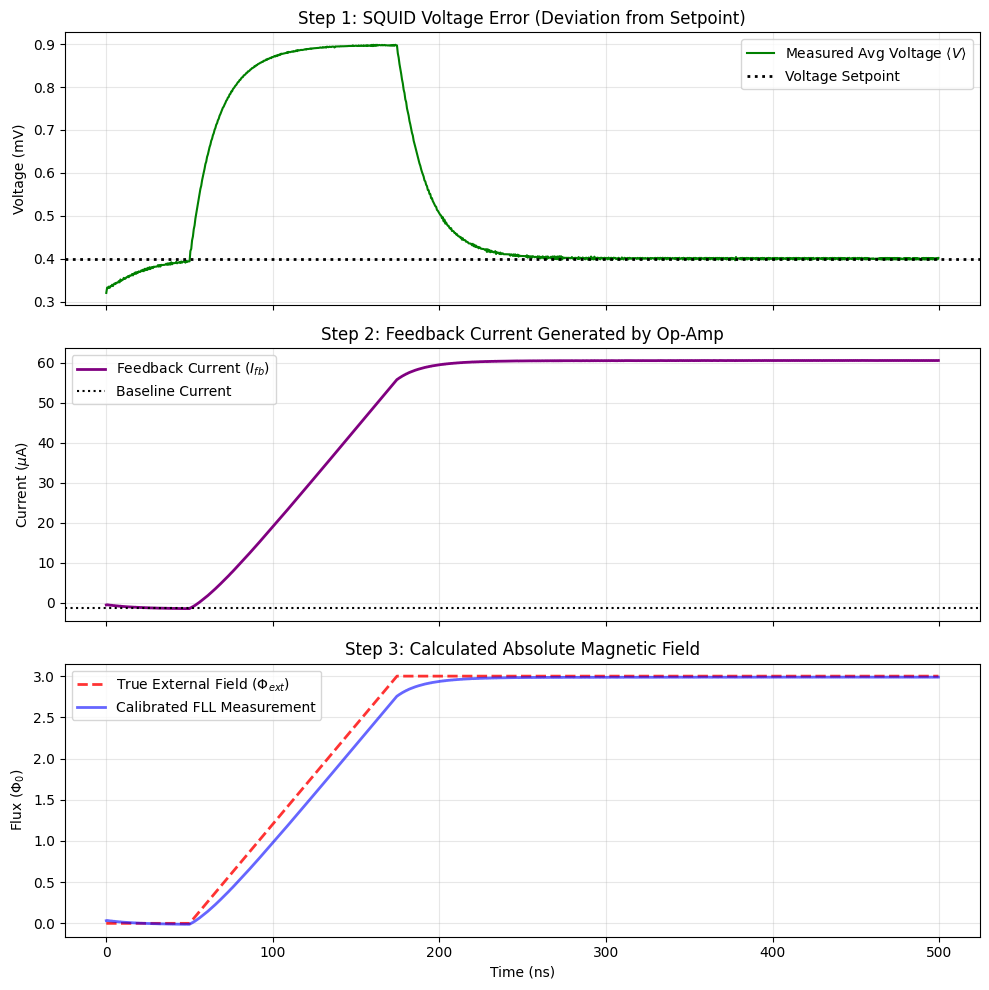

In [45]:
# --- Experimental Feedback Parameters ---
M_f = 100e-12         # Mutual inductance of feedback coil [Henries] (100 pH)

# The PI controller Op-Amp outputs CURRENT [Amps], not Flux
Kp_amp = 7.0e-3         # Proportional Gain [Amps/Volt]
Ki_amp = 5.0e-4       # Integral Gain [Amps/(Volt*second)]
V_setpoint = 0.4e-3   # Target lock voltage [Volts]

# --- Chunked Simulation Timing ---
chunk_dt = 1e-12      # Physics integration step [1 ps]
chunk_size = 500      # Steps per controller update [500 ps windows]
total_chunks = 1000
t_chunk = np.linspace(0, chunk_dt * chunk_size, chunk_size)

# --- Define External Field Ramp (The 'Unknown' Signal) ---
external_field_strength = 3.0 * PHI_0
phi_external = np.zeros(total_chunks)
ramp_start = 100
ramp_end = 350
phi_external[ramp_start:ramp_end] = np.linspace(0, external_field_strength, ramp_end - ramp_start)
phi_external[ramp_end:] = external_field_strength

# Controller state variables
current_feedback_list = []
v_avg_list = []
phi_current = 0.0
phi_current_fb = 0.0  # Physical current (I_fb) starts at 0 Amps
integral_error = 0.0

print("Simulating Physical Flux-Locked Loop...")

# --- FLL Feedback Loop ---
for i in range(total_chunks):
    # 1. Physical Flux Coupling (Phi_fb = M * I_fb)
    # The coil generates a magnetic flux proportional to the current running through it
    feedback_flux = M_f * phi_current_fb 
    
    # Calculate the net flux actually penetrating the SQUID loop
    phi_net = phi_external[i] - feedback_flux
    I_squid = 2 * Ic * np.abs(np.cos(np.pi * phi_net / PHI_0))
    
    # 2. Physics Integration (The SQUID's quantum response)
    sol = odeint(squid_deriv, phi_current, t_chunk, args=(I_squid,))
    phi_current = sol[-1, 0] # Save end state for next chunk
    
    # 3. Read Voltage (The input to your Op-Amp)
    v_chunk = (PHI_0 / (2 * np.pi)) * np.diff(sol[:, 0]) / chunk_dt
    v_avg = np.mean(v_chunk)
    
    # 4. Op-Amp calculates the Error
    error = v_avg - V_setpoint
    integral_error += error
    
    # 5. Op-Amp generates the physical Feedback Current (I_fb)
    phi_current_fb = (Kp_amp * error) + (Ki_amp * integral_error)
    
    # Record the physical current and voltage
    current_feedback_list.append(phi_current_fb)
    v_avg_list.append(v_avg)

# --- Calibration and Data Processing ---
raw_current_measurement = np.array(current_feedback_list)

# 1. Establish the baseline lock-current (Zero-field offset)
baseline_current_offset = np.mean(raw_current_measurement[20:80])

# 2. To find the external field, subtract the baseline current, 
# then multiply the remaining current by the mutual inductance (M_f)
calibrated_field_measurement = (raw_current_measurement - baseline_current_offset) * M_f

# Convert arrays for clean plotting
time_axis = np.arange(total_chunks) * (chunk_dt * chunk_size) * 1e9 # [ns]
v_avg_array = np.array(v_avg_list) * 1e3                            # [mV]
v_set_mV = V_setpoint * 1e3                                         # [mV]
current_uA = raw_current_measurement * 1e6                          # [Microamps]

# --- Plotting FLL Tracking ---
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# Top Plot: Voltage Error Tracking (The Input Signal)
ax1.plot(time_axis, v_avg_array, color='green', linewidth=1.5, label=r'Measured Avg Voltage $\langle V \rangle$')
ax1.axhline(v_set_mV, color='black', linestyle=':', linewidth=2, label='Voltage Setpoint')
ax1.set_ylabel('Voltage (mV)')
ax1.set_title('Step 1: SQUID Voltage Error (Deviation from Setpoint)')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Middle Plot: Physical Current (The Raw Data)
ax2.plot(time_axis, current_uA, color='purple', linewidth=2, label=r'Feedback Current ($I_{fb}$)')
ax2.axhline(baseline_current_offset * 1e6, color='black', linestyle=':', label='Baseline Current')
ax2.set_ylabel(r'Current ($\mu$A)')
ax2.set_title('Step 2: Feedback Current Generated by Op-Amp')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

# Bottom Plot: Field Tracking (The Final Measurement)
ax3.plot(time_axis, phi_external / PHI_0, 'r--', alpha=0.8, linewidth=2, label=r'True External Field ($\Phi_{ext}$)')
ax3.plot(time_axis, calibrated_field_measurement / PHI_0, 'b-', alpha=0.6, linewidth=2, label='Calibrated FLL Measurement')
ax3.set_ylabel(r'Flux ($\Phi_0$)')
ax3.set_xlabel('Time (ns)')
ax3.set_title('Step 3: Calculated Absolute Magnetic Field')
ax3.legend(loc='upper left')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()